分類結果
              precision    recall  f1-score   support

           0       0.56      0.71      0.63        52
           1       0.50      0.34      0.41        44

    accuracy                           0.54        96
   macro avg       0.53      0.53      0.52        96
weighted avg       0.53      0.54      0.53        96

SHAP重要度
         feature  mean_abs_shap
2           ma25       0.444037
6    return_lag3       0.290942
5    return_lag2       0.260451
4    return_lag1       0.224576
8   return_lag10       0.209364
7    return_lag5       0.184039
9     price_lag1       0.159868
0         return       0.134164
3    volatility5       0.105637
1            ma5       0.101462
13   price_lag10       0.089071
12    price_lag5       0.067944
11    price_lag3       0.052631
10    price_lag2       0.039064


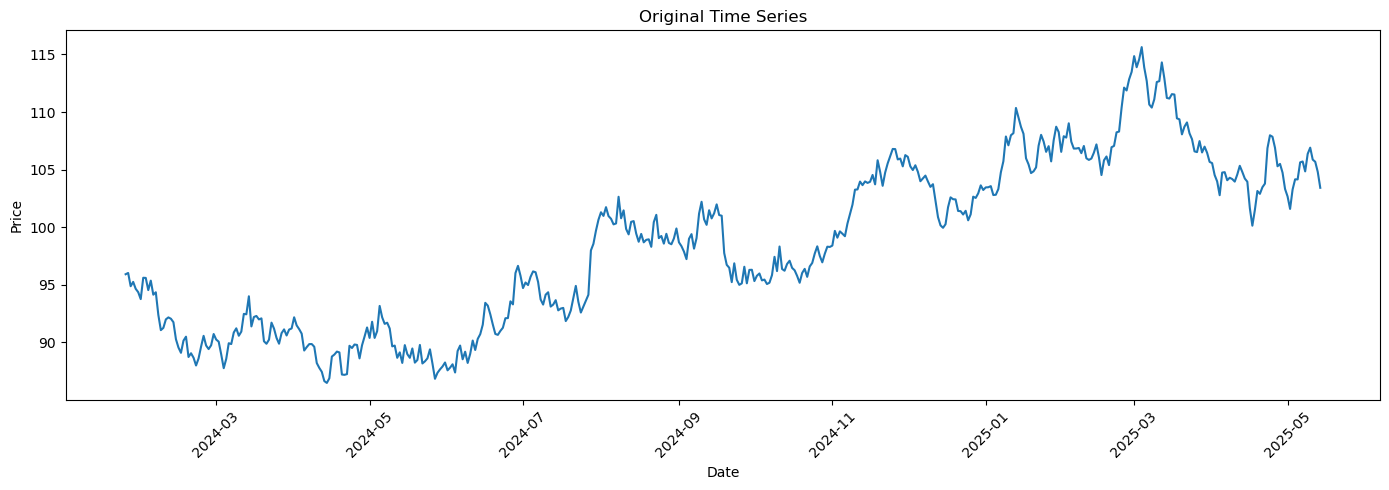

C:\Users\user\AppData\Local\Temp\ipykernel_14664\3086488076.py:180: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


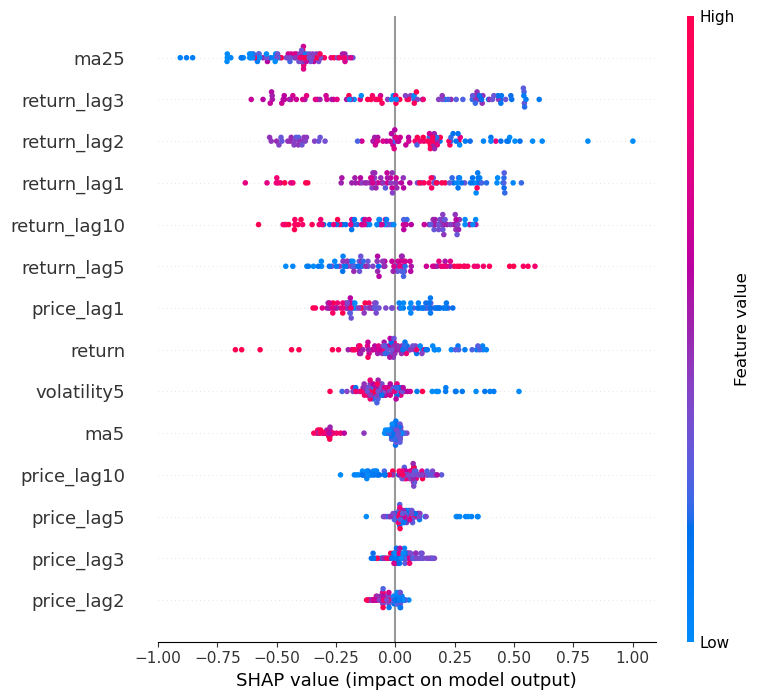

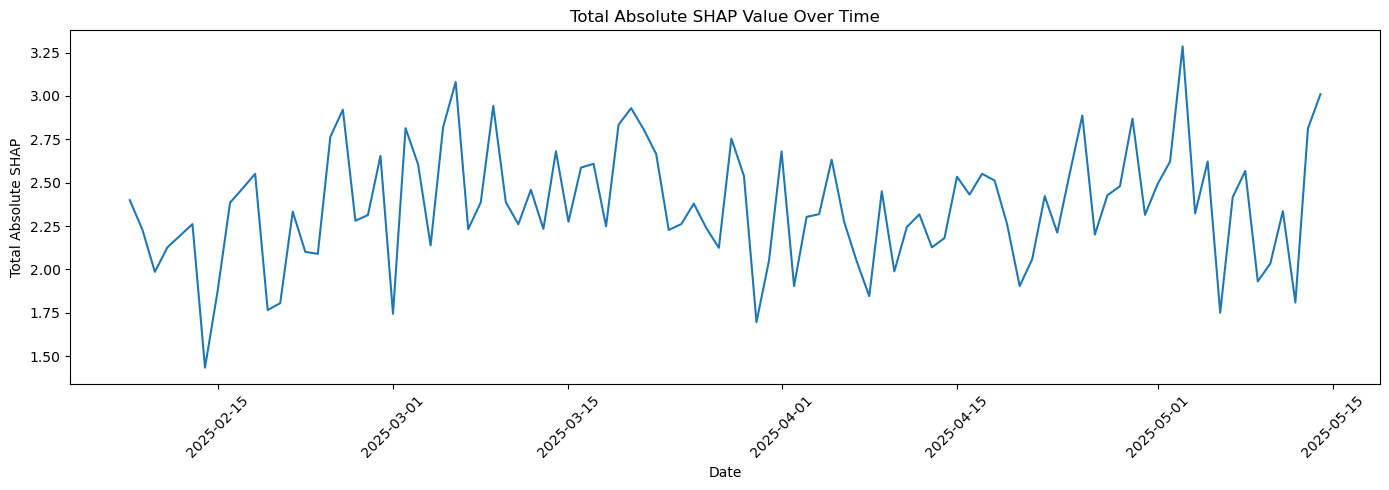

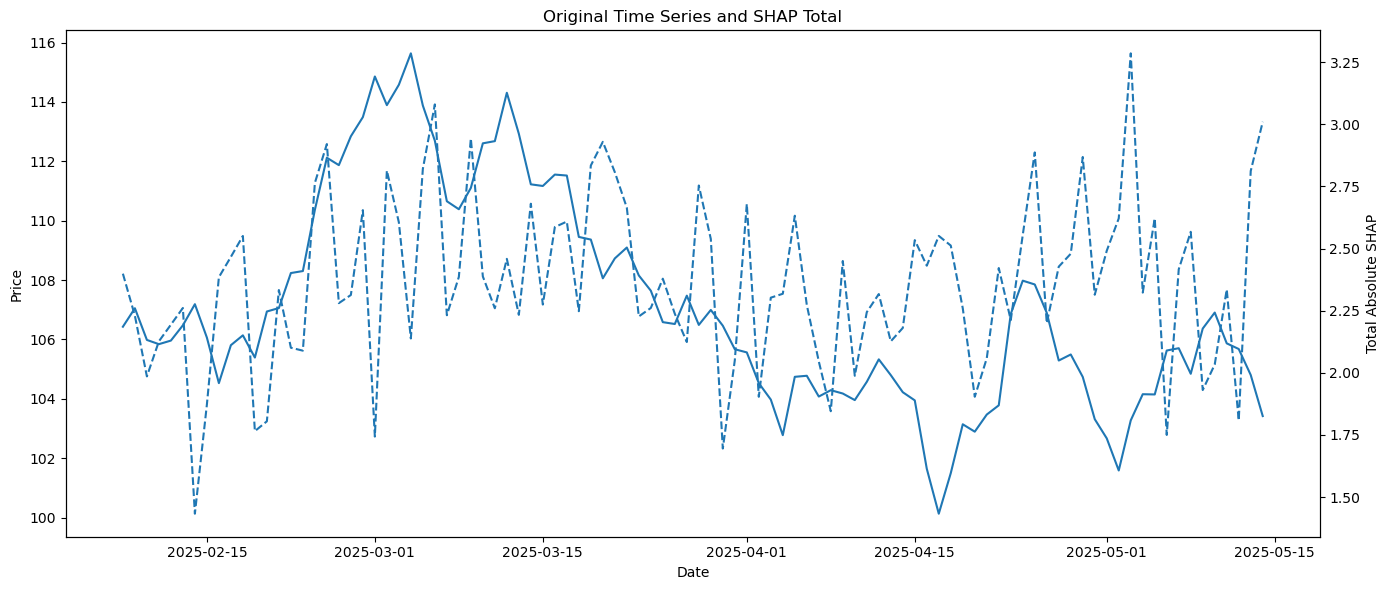

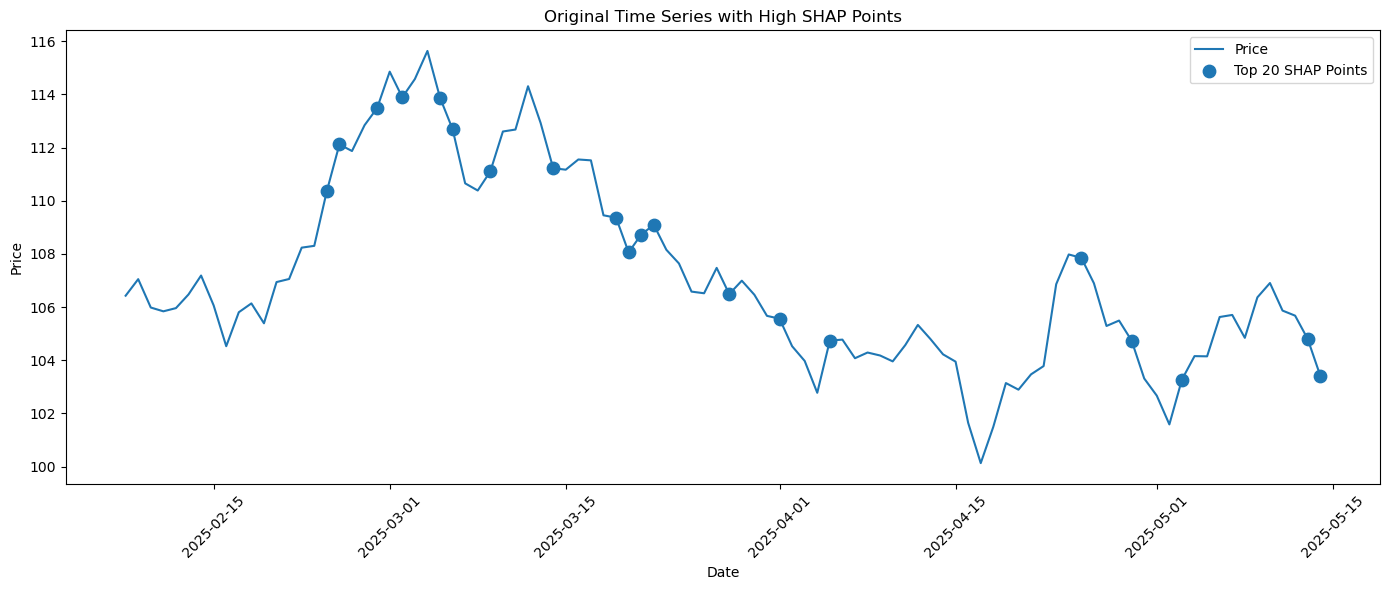

保存したフォルダ
timeseries_shap_outputs

主な保存ファイル
original_timeseries.png
shap_summary_plot.png
timeseries_shap_feature_importance.csv
timeseries_shap_by_date.csv
top_shap_points.csv
shap_target_feature_timeseries.csv
shap_values_by_feature.csv
feature_timeseries_and_shap_values.csv

各特徴量について保存される画像
feature_timeseries_<feature>.png
shap_timeseries_<feature>.png
feature_and_shap_timeseries_<feature>.png
feature_value_vs_shap_<feature>.png


In [1]:
# pip install pandas numpy matplotlib scikit-learn xgboost shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import shap


# =====================================================
# 0. 設定
# =====================================================

OUTPUT_DIR = Path("timeseries_shap_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

np.random.seed(42)


# =====================================================
# 1. サンプル時系列データ作成
# =====================================================

n = 500
date = pd.date_range("2024-01-01", periods=n, freq="D")

price = 100 + np.cumsum(np.random.normal(0, 1, n))

df = pd.DataFrame({
    "date": date,
    "price": price
})


# =====================================================
# 2. 基本特徴量
# =====================================================

df["return"] = df["price"].pct_change()
df["ma5"] = df["price"].rolling(5).mean()
df["ma25"] = df["price"].rolling(25).mean()
df["volatility5"] = df["return"].rolling(5).std()


# =====================================================
# 3. ラグ特徴量
# =====================================================

for lag in [1, 2, 3, 5, 10]:
    df[f"return_lag{lag}"] = df["return"].shift(lag)
    df[f"price_lag{lag}"] = df["price"].shift(lag)


# =====================================================
# 4. 目的変数
#    翌日の価格が上がれば1、下がれば0
# =====================================================

df["target"] = (df["price"].shift(-1) > df["price"]).astype(int)

df = df.dropna().reset_index(drop=True)


# =====================================================
# 5. 説明変数
# =====================================================

feature_cols = [
    "return",
    "ma5",
    "ma25",
    "volatility5",
    "return_lag1",
    "return_lag2",
    "return_lag3",
    "return_lag5",
    "return_lag10",
    "price_lag1",
    "price_lag2",
    "price_lag3",
    "price_lag5",
    "price_lag10",
]

X = df[feature_cols]
y = df["target"]


# =====================================================
# 6. 時系列分割
#    shuffleしない
# =====================================================

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

date_test = df["date"].iloc[split:].reset_index(drop=True)
price_test = df["price"].iloc[split:].reset_index(drop=True)


# =====================================================
# 7. モデル学習
# =====================================================

model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("分類結果")
print(classification_report(y_test, pred))


# =====================================================
# 8. SHAP値計算
# =====================================================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]


# =====================================================
# 9. SHAP重要度
# =====================================================

shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("SHAP重要度")
print(shap_importance)

shap_importance.to_csv(
    OUTPUT_DIR / "timeseries_shap_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 10. 元データをプロット
# =====================================================

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["price"])
plt.title("Original Time Series")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "original_timeseries.png", dpi=150)
plt.show()


# =====================================================
# 11. SHAP summary plot
# =====================================================

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary_plot.png", dpi=150)
plt.show()


# =====================================================
# 12. SHAP対象の特徴量時系列をすべてプロット
# =====================================================

for feature in feature_cols:
    plt.figure(figsize=(14, 5))
    plt.plot(date_test, X_test[feature].reset_index(drop=True))
    plt.title(f"Feature Time Series: {feature}")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"feature_timeseries_{feature}.png", dpi=150)
    plt.close()


# =====================================================
# 13. 特徴量ごとのSHAP時系列プロット
# =====================================================

for feature in feature_cols:
    feature_index = list(X_test.columns).index(feature)

    plt.figure(figsize=(14, 5))
    plt.plot(date_test, shap_values[:, feature_index])
    plt.axhline(0, linestyle="--")
    plt.title(f"SHAP Value Over Time: {feature}")
    plt.xlabel("Date")
    plt.ylabel("SHAP Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"shap_timeseries_{feature}.png", dpi=150)
    plt.close()


# =====================================================
# 14. 特徴量時系列 + SHAP時系列を上下2段でプロット
# =====================================================

for feature in feature_cols:
    feature_index = list(X_test.columns).index(feature)
    feature_series = X_test[feature].reset_index(drop=True)

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        sharex=True
    )

    ax1.plot(date_test, feature_series)
    ax1.set_title(f"Feature Time Series: {feature}")
    ax1.set_ylabel(feature)

    ax2.plot(date_test, shap_values[:, feature_index])
    ax2.axhline(0, linestyle="--")
    ax2.set_title(f"SHAP Value Over Time: {feature}")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("SHAP Value")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"feature_and_shap_timeseries_{feature}.png", dpi=150)
    plt.close()


# =====================================================
# 15. 特徴量の値 vs SHAP値の散布図
# =====================================================

for feature in feature_cols:
    feature_index = list(X_test.columns).index(feature)

    plt.figure(figsize=(7, 5))
    plt.scatter(
        X_test[feature],
        shap_values[:, feature_index],
        alpha=0.7
    )
    plt.axhline(0, linestyle="--")
    plt.title(f"Feature Value vs SHAP Value: {feature}")
    plt.xlabel(feature)
    plt.ylabel("SHAP Value")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"feature_value_vs_shap_{feature}.png", dpi=150)
    plt.close()


# =====================================================
# 16. 各時点のSHAP総量
# =====================================================

df_shap_time = pd.DataFrame({
    "date": date_test,
    "price": price_test,
    "shap_total_abs": np.abs(shap_values).sum(axis=1),
    "pred": pred,
    "actual": y_test.reset_index(drop=True)
})

df_shap_time.to_csv(
    OUTPUT_DIR / "timeseries_shap_by_date.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 17. SHAP総量を時系列でプロット
# =====================================================

plt.figure(figsize=(14, 5))
plt.plot(df_shap_time["date"], df_shap_time["shap_total_abs"])
plt.title("Total Absolute SHAP Value Over Time")
plt.xlabel("Date")
plt.ylabel("Total Absolute SHAP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_total_abs_over_time.png", dpi=150)
plt.show()


# =====================================================
# 18. 元データ価格 + SHAP総量
# =====================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    df_shap_time["date"],
    df_shap_time["price"],
    label="Price"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Price")

ax2 = ax1.twinx()

ax2.plot(
    df_shap_time["date"],
    df_shap_time["shap_total_abs"],
    linestyle="--",
    label="Total Absolute SHAP"
)

ax2.set_ylabel("Total Absolute SHAP")

plt.title("Original Time Series and SHAP Total")

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "price_vs_shap_total.png", dpi=150)
plt.show()


# =====================================================
# 19. SHAPが大きい上位20点を価格チャート上に表示
# =====================================================

top_n = 20

top_idx = df_shap_time["shap_total_abs"].nlargest(top_n).index

plt.figure(figsize=(14, 6))

plt.plot(
    df_shap_time["date"],
    df_shap_time["price"],
    label="Price"
)

plt.scatter(
    df_shap_time.loc[top_idx, "date"],
    df_shap_time.loc[top_idx, "price"],
    s=80,
    label=f"Top {top_n} SHAP Points"
)

plt.title("Original Time Series with High SHAP Points")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "original_timeseries_with_high_shap_points.png", dpi=150)
plt.show()


# =====================================================
# 20. 上位SHAP点をCSV保存
# =====================================================

df_top_shap = df_shap_time.loc[top_idx].sort_values(
    "shap_total_abs",
    ascending=False
)

df_top_shap.to_csv(
    OUTPUT_DIR / "top_shap_points.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 21. SHAP対象データもCSV保存
# =====================================================

df_feature_timeseries = X_test.copy().reset_index(drop=True)
df_feature_timeseries.insert(0, "date", date_test)

df_feature_timeseries.to_csv(
    OUTPUT_DIR / "shap_target_feature_timeseries.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 22. SHAP値そのものもCSV保存
# =====================================================

df_shap_values = pd.DataFrame(
    shap_values,
    columns=[f"shap_{c}" for c in feature_cols]
)

df_shap_values.insert(0, "date", date_test)

df_shap_values.to_csv(
    OUTPUT_DIR / "shap_values_by_feature.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 23. 特徴量 + SHAP値を横結合して保存
# =====================================================

df_feature_and_shap = pd.concat(
    [
        df_feature_timeseries,
        df_shap_values.drop(columns=["date"])
    ],
    axis=1
)

df_feature_and_shap.to_csv(
    OUTPUT_DIR / "feature_timeseries_and_shap_values.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 24. 保存ファイル一覧
# =====================================================

print("保存したフォルダ")
print(OUTPUT_DIR)

print("\n主な保存ファイル")
print("original_timeseries.png")
print("shap_summary_plot.png")
print("timeseries_shap_feature_importance.csv")
print("timeseries_shap_by_date.csv")
print("top_shap_points.csv")
print("shap_target_feature_timeseries.csv")
print("shap_values_by_feature.csv")
print("feature_timeseries_and_shap_values.csv")

print("\n各特徴量について保存される画像")
print("feature_timeseries_<feature>.png")
print("shap_timeseries_<feature>.png")
print("feature_and_shap_timeseries_<feature>.png")
print("feature_value_vs_shap_<feature>.png")